# Imports

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Data Loading

In [2]:
df = pd.read_csv('rounded_hours_student_scores.csv')

In [3]:
df.head()

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


# Data Preprocessing

In [4]:
X = df[['Hours']]
y = df['Scores']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

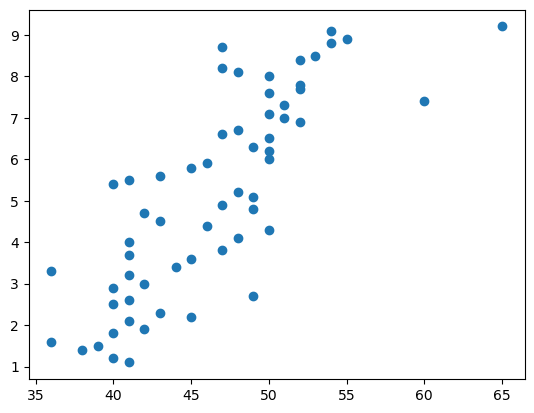

In [5]:
plt.scatter(y, X)

# ML Pipeline & Model Training

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(3)),
    ('model', LinearRegression())
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3)),
                ('model', LinearRegression())])

# Evaluation

In [7]:
y_pred = pipeline.predict(X_test)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error (MSE): 16.81440707233592
R2 Score: 0.5502833175303914


# Save Model

In [8]:
with open('student_scores_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("Model saved as student_scores_model.pkl")

Model saved as student_scores_model.pkl
